# 🚀 FinSight AI — Agentic FP&A & ERP Analytics Copilot

### AI-powered financial analysis using Python, SQL, Machine Learning and agentic reasoning

**Portfolio Project | Finance + Data Analytics + AI + Product Management**

---

## 📌 What does FinSight AI do?

FinSight AI acts as a finance analytics copilot that accepts natural-language business questions and routes them to the appropriate analytical capability.

For example:

> **"Why is spending above budget?"**

The system can perform:

**SQL variance analysis → ML anomaly detection → forecasting → business interpretation → recommended action**

### Technology Stack

`Python` · `SQL` · `SQLite` · `Pandas` · `Scikit-learn` · `Matplotlib` · `Agentic AI` · `FP&A`

### Dataset

Synthetic ERP-style financial data created specifically for this portfolio project.

**No confidential company or client data is used.**

# 🚀 FinSight AI — Agentic FP&A & ERP Analytics Copilot

## Overview

FinSight AI is a finance-focused agentic analytics prototype that combines:

- **Python** for data processing and financial analytics
- **SQL** for structured FP&A analysis
- **Machine Learning** for financial anomaly detection
- **Revenue Forecasting** for forward-looking planning
- **Data Visualization** for management reporting
- **Agentic reasoning** for natural-language finance questions
- **Product Management concepts** for converting insights into prioritized actions

The project is designed around a realistic FP&A workflow:

> **Ask a business question → select the appropriate analytical tool → retrieve verified evidence → interpret the result → recommend an action**

---

## Business Problem

Finance and business teams often spend significant time converting raw ERP-style data into:

- Budget vs Actual analysis
- Variance explanations
- Cost-driver analysis
- Risk and anomaly identification
- Revenue forecasts
- Management actions

FinSight AI demonstrates how an agentic analytics workflow can reduce the effort required to move from **financial data → insight → action**.

---

## Key Capabilities

| Capability | Implementation |
|---|---|
| Budget vs Actual | SQL |
| Variance Analysis | Python + SQL |
| Cost Driver Analysis | SQL |
| Anomaly Detection | Isolation Forest |
| Revenue Forecasting | Linear Regression |
| Visualization | Matplotlib |
| Natural Language Agent | Python routing layer |
| Management Recommendations | Structured AI reasoning |
| PM Action Tracking | Priority + Owner + Status |

---

## Important Design Principle

The system separates **financial computation** from **AI reasoning**.

Financial metrics are calculated using Python and SQL first.  
The reasoning layer then interprets the verified analytical evidence.

This design helps reduce the risk of generating unsupported financial figures.

---

## Dataset

The project uses a **synthetic ERP-style financial dataset** created specifically for this portfolio project.

No confidential company, client or employer data is used.

# 🏗️ System Architecture

```text
                    USER
                     │
                     ▼
          Natural Language Question
                     │
                     ▼
              Finance Agent
                     │
          ┌──────────┼──────────┐
          ▼          ▼          ▼
        SQL         ML       Forecasting
        Tool        Tool        Tool
          │          │          │
          └──────────┼──────────┘
                     ▼
              Verified Evidence
                     │
                     ▼
             Reasoning Layer
                     │
                     ▼
             Business Insight
                     │
                     ▼
          Recommended Action
                     │
              ┌──────┴──────┐
              ▼             ▼
          Priority         Owner

In [1]:
# ============================================================
# FinSight AI - Agentic FP&A & ERP Analytics Copilot
# STEP 1: Project Setup
# ============================================================

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error

from datetime import datetime

print("✅ FinSight AI project environment started successfully!")
print("Python + Pandas + SQL + ML + Visualization libraries loaded.")

✅ FinSight AI project environment started successfully!
Python + Pandas + SQL + ML + Visualization libraries loaded.


In [2]:
# ============================================================
# STEP 2: REALISTIC SYNTHETIC ERP-STYLE FINANCE DATASET
# ============================================================

np.random.seed(42)

n = 720

# ------------------------------------------------------------
# MASTER DIMENSIONS
# ------------------------------------------------------------

business_units = [
    "India",
    "North America",
    "Europe",
    "Asia Pacific",
    "Middle East"
]

departments = [
    "Engineering",
    "Sales",
    "Marketing",
    "HR",
    "Finance",
    "Operations"
]

accounts = [
    "Payroll",
    "Cloud Infrastructure",
    "Software Licenses",
    "Travel",
    "Professional Services",
    "Office & Facilities",
    "Marketing",
    "Training"
]

# ------------------------------------------------------------
# CREATE BASE ERP TRANSACTION DATA
# ------------------------------------------------------------

df = pd.DataFrame({
    "transaction_id": [
        f"ERP-{i:05d}" for i in range(1, n + 1)
    ],
    
    "date": pd.date_range(
        start="2025-01-01",
        end="2026-06-30",
        periods=n
    ),
    
    "business_unit": np.random.choice(
        business_units,
        n
    ),
    
    "department": np.random.choice(
        departments,
        n
    ),
    
    "account": np.random.choice(
        accounts,
        n
    )
})

# ------------------------------------------------------------
# BASE BUDGET
# ------------------------------------------------------------

df["budget"] = np.random.uniform(
    30000,
    180000,
    n
).round(2)

# ------------------------------------------------------------
# BUSINESS SCENARIO FACTORS
# ------------------------------------------------------------

df["actual_factor"] = 1.00

# North America → Cloud Infrastructure overspend
mask = (
    (df["business_unit"] == "North America") &
    (df["account"] == "Cloud Infrastructure")
)

df.loc[mask, "actual_factor"] = 1.35

# Asia Pacific → Professional Services spike
mask = (
    (df["business_unit"] == "Asia Pacific") &
    (df["account"] == "Professional Services")
)

df.loc[mask, "actual_factor"] = 1.30

# Europe → Travel underspend
mask = (
    (df["business_unit"] == "Europe") &
    (df["account"] == "Travel")
)

df.loc[mask, "actual_factor"] = 0.75

# India → Payroll relatively stable
mask = (
    (df["business_unit"] == "India") &
    (df["account"] == "Payroll")
)

df.loc[mask, "actual_factor"] = 1.02

# Middle East → Marketing variance
mask = (
    (df["business_unit"] == "Middle East") &
    (df["account"] == "Marketing")
)

df.loc[mask, "actual_factor"] = 1.22

# ------------------------------------------------------------
# GENERIC BUSINESS VARIATION
# ------------------------------------------------------------

noise = np.random.normal(
    loc=0,
    scale=0.08,
    size=n
)

df["actual"] = (
    df["budget"] *
    (df["actual_factor"] + noise)
).clip(lower=5000).round(2)

# ------------------------------------------------------------
# REVENUE MODEL
# ------------------------------------------------------------

business_revenue_factor = {
    "India": 1.00,
    "North America": 1.55,
    "Europe": 1.25,
    "Asia Pacific": 1.15,
    "Middle East": 0.95
}

df["revenue"] = (
    df["budget"]
    * 2.4
    * df["business_unit"].map(business_revenue_factor)
    * np.random.normal(1.0, 0.12, n)
).clip(lower=50000).round(2)

# ------------------------------------------------------------
# INJECT A FEW HIGH-VARIANCE TRANSACTIONS
# ------------------------------------------------------------

anomaly_indices = np.random.choice(
    df.index,
    size=18,
    replace=False
)

df.loc[anomaly_indices, "actual"] = (
    df.loc[anomaly_indices, "budget"]
    * np.random.uniform(2.0, 3.0, len(anomaly_indices))
).round(2)

# ------------------------------------------------------------
# CALCULATE FINANCIAL METRICS
# ------------------------------------------------------------

df["variance"] = (
    df["actual"] - df["budget"]
).round(2)

df["variance_pct"] = (
    df["variance"] /
    df["budget"] *
    100
).round(2)

df["profit"] = (
    df["revenue"] - df["actual"]
).round(2)

# Remove helper column
df.drop(
    columns=["actual_factor"],
    inplace=True
)

# ------------------------------------------------------------
# FINAL OUTPUT
# ------------------------------------------------------------

print("✅ Realistic synthetic ERP dataset created.")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

print("\nBusiness units:")
print(df["business_unit"].value_counts())

print("\nAccounts:")
print(df["account"].value_counts())

print("\nDataset preview:")
display(df.head())

✅ Realistic synthetic ERP dataset created.
Rows: 720
Columns: 11

Business units:
business_unit
Asia Pacific     154
India            154
Middle East      148
North America    136
Europe           128
Name: count, dtype: int64

Accounts:
account
Travel                   96
Professional Services    95
Office & Facilities      93
Cloud Infrastructure     92
Payroll                  89
Software Licenses        89
Training                 86
Marketing                80
Name: count, dtype: int64

Dataset preview:


,transaction_id,date,business_unit,department,account,budget,actual,revenue,variance,variance_pct,profit
0,ERP-00001,2025-01-01 00:00:00.000000000,Asia Pacific,Operations,Cloud Infrastructure,101194.63,110494.28,311084.99,9299.65,9.19,200590.71
1,ERP-00002,2025-01-01 18:11:30.959666203,Middle East,Marketing,Travel,156625.57,174572.88,301999.59,17947.31,11.46,127426.71
2,ERP-00003,2025-01-02 12:23:01.919332406,Europe,Marketing,Office & Facilities,150850.52,136501.48,457307.60,-14349.04,-9.51,320806.12
3,ERP-00004,2025-01-03 06:34:32.878998609,Middle East,Sales,Cloud Infrastructure,117803.15,115397.59,281352.56,-2405.56,-2.04,165954.97
4,ERP-00005,2025-01-04 00:46:03.838664812,Middle East,HR,Marketing,160240.69,321517.23,361693.05,161276.54,100.65,40175.82


In [3]:
# ============================================================
# STEP 3: Basic Financial Data Quality Check
# ============================================================

print("Dataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFinancial summary:")
display(df.describe())

Dataset shape:
(720, 11)

Missing values:
transaction_id    0
date              0
business_unit     0
department        0
account           0
budget            0
actual            0
revenue           0
variance          0
variance_pct      0
profit            0
dtype: int64

Financial summary:


,date,budget,actual,revenue,variance,variance_pct,profit
count,720,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2025-09-30 12:00:00,105413.276681,110228.826389,297115.083806,4815.549708,4.474264,186886.257417
min,2025-01-01 00:00:00,30482.740000,25631.770000,62394.000000,-42572.780000,-44.220000,-91121.850000
25%,2025-05-17 06:00:00,67035.572500,69567.192500,183323.160000,-5179.090000,-5.702500,101515.445000
50%,2025-09-30 12:00:00,107107.400000,107106.855000,281174.910000,381.065000,0.325000,163958.360000
75%,2026-02-13 18:00:00,143324.045000,146293.085000,392786.830000,6411.780000,7.222500,255599.550000
max,2026-06-30 00:00:00,179912.060000,480547.660000,806763.240000,308692.940000,179.620000,659623.830000
std,NaN,43393.639016,54649.729243,144531.940979,30022.932767,25.685993,110381.379083


In [4]:
# ============================================================
# STEP 4: Create SQL Database
# ============================================================

# Create an in-memory SQLite database
conn = sqlite3.connect(":memory:")

# Send our Pandas dataframe into SQL
df.to_sql("financials", conn, index=False, if_exists="replace")

print("✅ Financial dataset loaded into SQLite.")
print("✅ SQL table created: financials")

✅ Financial dataset loaded into SQLite.
✅ SQL table created: financials


In [5]:
# ============================================================
# STEP 5: SQL - Budget vs Actual by Business Unit
# ============================================================

query = """
SELECT
    business_unit,
    ROUND(SUM(budget), 2) AS total_budget,
    ROUND(SUM(actual), 2) AS total_actual,
    ROUND(SUM(actual - budget), 2) AS variance,
    ROUND((SUM(actual) - SUM(budget)) * 100.0 / SUM(budget), 2) AS variance_pct
FROM financials
GROUP BY business_unit
ORDER BY variance DESC;
"""

business_unit_analysis = pd.read_sql_query(query, conn)

business_unit_analysis

,business_unit,total_budget,total_actual,variance,variance_pct
0,North America,15436559.43,16970883.75,1534324.32,9.94
1,Middle East,15458726.01,16232102.13,773376.12,5.00
2,Asia Pacific,15730895.27,16449629.81,718734.54,4.57
3,India,16341134.66,17017403.72,676269.06,4.14
4,Europe,12930243.84,12694735.59,-235508.25,-1.82


In [6]:
# ============================================================
# STEP 6: SQL - Top Cost Drivers
# ============================================================

query = """
SELECT
    account,
    ROUND(SUM(budget), 2) AS budget,
    ROUND(SUM(actual), 2) AS actual,
    ROUND(SUM(actual - budget), 2) AS variance,
    ROUND((SUM(actual) - SUM(budget)) * 100.0 / SUM(budget), 2) AS variance_pct
FROM financials
GROUP BY account
ORDER BY variance DESC
LIMIT 10;
"""

top_cost_drivers = pd.read_sql_query(query, conn)

top_cost_drivers

,account,budget,actual,variance,variance_pct
0,Cloud Infrastructure,9431703.12,10814673.93,1382970.81,14.66
1,Marketing,8881438.80,9437002.03,555563.23,6.26
2,Professional Services,9550651.09,10061189.47,510538.38,5.35
3,Training,8645950.64,9034743.05,388792.41,4.50
4,Travel,10544005.48,10932014.71,388009.23,3.68
5,Office & Facilities,10350362.38,10468875.26,118512.88,1.15
6,Software Licenses,9282985.28,9363874.95,80889.67,0.87
7,Payroll,9210462.42,9252381.60,41919.18,0.46


In [7]:
# ============================================================
# STEP 7: SQL - Department Variance Analysis
# ============================================================

query = """
SELECT
    department,
    ROUND(SUM(budget), 2) AS total_budget,
    ROUND(SUM(actual), 2) AS total_actual,
    ROUND(SUM(actual - budget), 2) AS variance,
    ROUND((SUM(actual) - SUM(budget)) * 100.0 / SUM(budget), 2) AS variance_pct
FROM financials
GROUP BY department
ORDER BY variance DESC;
"""

department_analysis = pd.read_sql_query(query, conn)

department_analysis

,department,total_budget,total_actual,variance,variance_pct
0,Marketing,13737151.33,14901027.49,1163876.16,8.47
1,Operations,13028111.35,13807488.88,779377.53,5.98
2,Sales,12794607.27,13360758.76,566151.49,4.42
3,HR,10435392.76,10952357.92,516965.16,4.95
4,Finance,12958597.20,13347782.19,389184.99,3.00
5,Engineering,12943699.30,12995339.76,51640.46,0.40


In [8]:
# ============================================================
# STEP 8: Executive FP&A Summary
# ============================================================

total_budget = df["budget"].sum()
total_actual = df["actual"].sum()
total_variance = total_actual - total_budget
variance_pct = (total_variance / total_budget) * 100

print("==============================================")
print("        FINSIGHT AI - FP&A SUMMARY")
print("==============================================")
print(f"Total Budget     : ₹{total_budget:,.2f}")
print(f"Total Actual     : ₹{total_actual:,.2f}")
print(f"Total Variance   : ₹{total_variance:,.2f}")
print(f"Variance %       : {variance_pct:.2f}%")
print("==============================================")

if total_variance > 0:
    print("⚠️ Overall spending is ABOVE budget.")
else:
    print("✅ Overall spending is BELOW budget.")

        FINSIGHT AI - FP&A SUMMARY
Total Budget     : ₹75,897,559.21
Total Actual     : ₹79,364,755.00
Total Variance   : ₹3,467,195.79
Variance %       : 4.57%
⚠️ Overall spending is ABOVE budget.


In [9]:
# ============================================================
# STEP 9: MACHINE LEARNING - FINANCIAL ANOMALY DETECTION
# ============================================================

from sklearn.ensemble import IsolationForest

# Select financial variables for anomaly detection
features = df[[
    "budget",
    "actual",
    "revenue",
    "variance"
]].copy()

# Create the ML model
anomaly_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

# Train the model
anomaly_model.fit(features)

# Predict anomalies
df["anomaly_flag"] = anomaly_model.predict(features)

# Convert results into easy-to-understand labels
df["anomaly"] = df["anomaly_flag"].map({
    1: "Normal",
    -1: "Anomaly"
})

# Display anomaly statistics
print("✅ Machine learning anomaly detection completed.")
print()

print("Transaction classification:")
print(df["anomaly"].value_counts())

print()

print("Number of anomalies detected:",
      (df["anomaly"] == "Anomaly").sum())

✅ Machine learning anomaly detection completed.

Transaction classification:
anomaly
Normal     684
Anomaly     36
Name: count, dtype: int64

Number of anomalies detected: 36


In [10]:
# ============================================================
# STEP 10: REVIEW FINANCIAL ANOMALIES
# ============================================================

anomalies = df[
    df["anomaly"] == "Anomaly"
].copy()

# Sort by absolute variance
anomalies["absolute_variance"] = anomalies["variance"].abs()

anomalies = anomalies.sort_values(
    "absolute_variance",
    ascending=False
)

print(f"Total anomalies identified: {len(anomalies)}")

display(
    anomalies[
        [
            "date",
            "business_unit",
            "department",
            "account",
            "budget",
            "actual",
            "variance",
            "variance_pct",
            "anomaly"
        ]
    ].head(15)
)

Total anomalies identified: 36


,date,business_unit,department,account,budget,actual,variance,variance_pct,anomaly
648,2026-05-07 04:22:21.863699584,India,Operations,Travel,171854.72,480547.66,308692.94,179.62,Anomaly
322,2025-09-02 01:48:09.012517388,North America,Marketing,Cloud Infrastructure,179504.53,460858.30,281353.77,156.74,Anomaly
607,2026-04-06 02:30:12.517385256,India,Marketing,Travel,165965.62,414289.89,248324.27,149.62,Anomaly
264,2025-07-20 02:40:13.351877608,Asia Pacific,Operations,Office & Facilities,152617.46,396698.45,244080.99,159.93,Anomaly
538,2026-02-12 19:15:36.300417248,North America,Sales,Cloud Infrastructure,136152.14,355371.78,219219.64,161.01,Anomaly
478,2025-12-29 07:44:38.720445064,Middle East,Marketing,Travel,144168.23,329883.51,185715.28,128.82,Anomaly
258,2025-07-15 13:31:07.593880390,North America,HR,Travel,104544.52,285931.90,181387.38,173.50,Anomaly
4,2025-01-04 00:46:03.838664812,Middle East,HR,Marketing,160240.69,321517.23,161276.54,100.65,Anomaly
142,2025-04-18 15:15:16.272600834,Asia Pacific,Finance,Cloud Infrastructure,112533.98,257210.59,144676.61,128.56,Anomaly
226,2025-06-21 07:22:36.884561892,North America,Finance,Cloud Infrastructure,82135.73,210587.22,128451.49,156.39,Anomaly


In [11]:
# ============================================================
# STEP 11: ANOMALY BUSINESS INSIGHTS
# ============================================================

anomaly_summary = (
    anomalies
    .groupby("account")
    .agg(
        anomaly_count=("account", "size"),
        total_variance=("variance", "sum"),
        average_variance_pct=("variance_pct", "mean")
    )
    .sort_values(
        "total_variance",
        ascending=False
    )
)

print("Top accounts associated with financial anomalies:")

display(anomaly_summary.head(10))

Top accounts associated with financial anomalies:


,anomaly_count,total_variance,average_variance_pct
account,,,
Cloud Infrastructure,10,1154093.10,90.528000
Travel,7,961186.04,93.254286
Training,5,336177.88,91.308000
Marketing,5,272106.11,55.472000
Office & Facilities,3,224201.57,49.530000
Professional Services,2,108801.32,84.235000
Software Licenses,3,95113.10,43.480000
Payroll,1,90404.11,173.460000


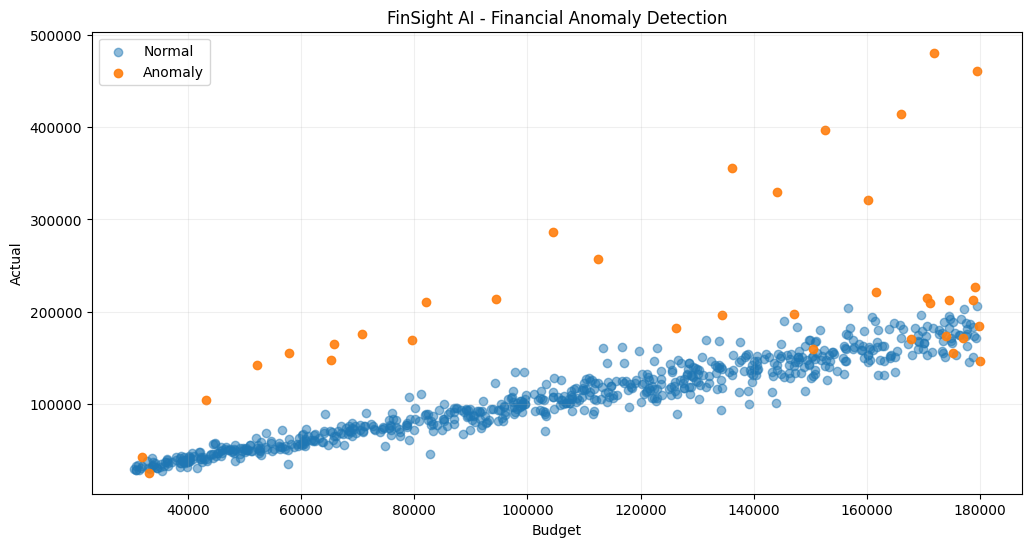

In [12]:
# ============================================================
# STEP 12: VISUALIZE ANOMALIES
# ============================================================

plt.figure(figsize=(12, 6))

normal = df[df["anomaly"] == "Normal"]
anomaly_data = df[df["anomaly"] == "Anomaly"]

plt.scatter(
    normal["budget"],
    normal["actual"],
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    anomaly_data["budget"],
    anomaly_data["actual"],
    alpha=0.9,
    label="Anomaly"
)

plt.xlabel("Budget")
plt.ylabel("Actual")
plt.title("FinSight AI - Financial Anomaly Detection")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [13]:
# ============================================================
# STEP 13: REVENUE FORECASTING
# ============================================================

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Aggregate revenue by month
monthly_revenue = (
    df.set_index("date")
      .resample("ME")["revenue"]
      .sum()
      .reset_index()
)

print("✅ Monthly revenue data created.")
display(monthly_revenue.head())

✅ Monthly revenue data created.


,date,revenue
0,2025-01-31,11892614.53
1,2025-02-28,13840877.38
2,2025-03-31,10523255.87
3,2025-04-30,11516228.20
4,2025-05-31,11164284.34


In [14]:
# ============================================================
# STEP 14: SIMPLE REVENUE FORECAST
# ============================================================

from sklearn.linear_model import LinearRegression

# Create a numeric time index
monthly_revenue["month_number"] = np.arange(len(monthly_revenue))

# Prepare training data
X = monthly_revenue[["month_number"]]
y = monthly_revenue["revenue"]

# Train the forecasting model
forecast_model = LinearRegression()
forecast_model.fit(X, y)

# Create future month numbers as a DataFrame
future_month_numbers = pd.DataFrame({
    "month_number": np.arange(
        len(monthly_revenue),
        len(monthly_revenue) + 6
    )
})

# Generate forecast
future_predictions = forecast_model.predict(
    future_month_numbers
)

# Create future month-end dates
future_dates = pd.date_range(
    start=monthly_revenue["date"].max() + pd.offsets.MonthEnd(1),
    periods=6,
    freq="ME"
)

# Create forecast dataframe
forecast_df = pd.DataFrame({
    "date": future_dates,
    "forecast_revenue": future_predictions
})

print("✅ Six-month revenue forecast generated.")
display(forecast_df)

✅ Six-month revenue forecast generated.


,date,forecast_revenue
0,2026-07-31,1.169108e+07
1,2026-08-31,1.167071e+07
2,2026-09-30,1.165034e+07
3,2026-10-31,1.162997e+07
4,2026-11-30,1.160960e+07
5,2026-12-31,1.158923e+07


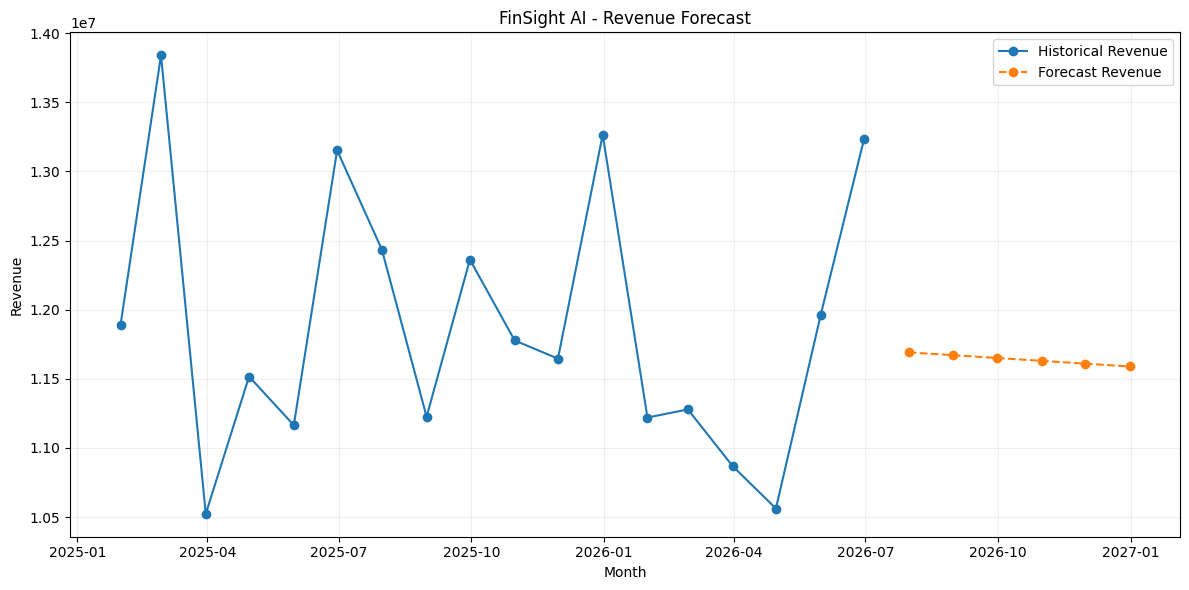

In [15]:
# ============================================================
# STEP 15: REVENUE FORECAST VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["date"],
    monthly_revenue["revenue"],
    marker="o",
    label="Historical Revenue"
)

plt.plot(
    forecast_df["date"],
    forecast_df["forecast_revenue"],
    marker="o",
    linestyle="--",
    label="Forecast Revenue"
)

plt.title("FinSight AI - Revenue Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# STEP 16: FINSIGHT AI - FINANCE AGENT
# ============================================================

def finance_agent(question):
    """
    Simple rule-based finance agent.

    The agent identifies the intent of a user's question
    and retrieves the appropriate analytical evidence.
    """

    question = question.lower().strip()

    # --------------------------------------------------------
    # 1. BUDGET VS ACTUAL
    # --------------------------------------------------------
    if (
        "budget" in question
        or "variance" in question
        or "overspend" in question
        or "spending" in question
    ):

        query = """
        SELECT
            business_unit,
            ROUND(SUM(budget), 2) AS budget,
            ROUND(SUM(actual), 2) AS actual,
            ROUND(SUM(actual - budget), 2) AS variance,
            ROUND(
                (SUM(actual) - SUM(budget)) * 100.0
                / SUM(budget),
                2
            ) AS variance_pct
        FROM financials
        GROUP BY business_unit
        ORDER BY variance DESC;
        """

        result = pd.read_sql_query(query, conn)

        return {
            "intent": "Budget vs Actual",
            "evidence": result,
            "message": (
                "I analyzed budget versus actual spending "
                "across business units."
            )
        }

    # --------------------------------------------------------
    # 2. COST DRIVERS
    # --------------------------------------------------------
    elif (
        "cost driver" in question
        or "cost drivers" in question
        or "expense" in question
    ):

        query = """
        SELECT
            account,
            ROUND(SUM(budget), 2) AS budget,
            ROUND(SUM(actual), 2) AS actual,
            ROUND(SUM(actual - budget), 2) AS variance,
            ROUND(
                (SUM(actual) - SUM(budget)) * 100.0
                / SUM(budget),
                2
            ) AS variance_pct
        FROM financials
        GROUP BY account
        ORDER BY variance DESC
        LIMIT 10;
        """

        result = pd.read_sql_query(query, conn)

        return {
            "intent": "Cost Driver Analysis",
            "evidence": result,
            "message": (
                "I identified the financial accounts "
                "contributing most to cost variance."
            )
        }

    # --------------------------------------------------------
    # 3. ANOMALIES
    # --------------------------------------------------------
    elif (
        "anomal" in question
        or "unusual" in question
        or "suspicious" in question
        or "risk" in question
    ):

        result = anomalies[
            [
                "date",
                "business_unit",
                "department",
                "account",
                "budget",
                "actual",
                "variance",
                "variance_pct"
            ]
        ].head(15)

        return {
            "intent": "Anomaly Detection",
            "evidence": result,
            "message": (
                "I identified transactions that "
                "deviate significantly from normal "
                "financial patterns."
            )
        }

    # --------------------------------------------------------
    # 4. FORECAST
    # --------------------------------------------------------
    elif (
        "forecast" in question
        or "future revenue" in question
        or "revenue" in question
    ):

        return {
            "intent": "Revenue Forecast",
            "evidence": forecast_df,
            "message": (
                "I generated a six-month revenue forecast "
                "using the historical monthly revenue trend."
            )
        }

    # --------------------------------------------------------
    # 5. DEFAULT
    # --------------------------------------------------------
    else:

        return {
            "intent": "General Finance Analysis",
            "evidence": None,
            "message": (
                "I can analyze budget variance, cost drivers, "
                "financial anomalies and revenue forecasts."
            )
        }


print("✅ FinSight AI Finance Agent created.")

✅ FinSight AI Finance Agent created.


In [17]:
# ============================================================
# STEP 17: TEST THE FINANCE AGENT
# ============================================================

question = "Which business units are overspending?"

response = finance_agent(question)

print("USER QUESTION:")
print(question)

print()
print("AGENT INTENT:")
print(response["intent"])

print()
print("AGENT MESSAGE:")
print(response["message"])

print()
print("EVIDENCE:")
display(response["evidence"])

USER QUESTION:
Which business units are overspending?

AGENT INTENT:
Budget vs Actual

AGENT MESSAGE:
I analyzed budget versus actual spending across business units.

EVIDENCE:


,business_unit,budget,actual,variance,variance_pct
0,North America,15436559.43,16970883.75,1534324.32,9.94
1,Middle East,15458726.01,16232102.13,773376.12,5.00
2,Asia Pacific,15730895.27,16449629.81,718734.54,4.57
3,India,16341134.66,17017403.72,676269.06,4.14
4,Europe,12930243.84,12694735.59,-235508.25,-1.82


In [18]:
# ============================================================
# STEP 18: TEST ANOMALY AGENT
# ============================================================

question = "Which transactions look unusual?"

response = finance_agent(question)

print("USER QUESTION:")
print(question)

print()
print("AGENT INTENT:")
print(response["intent"])

print()
print("AGENT MESSAGE:")
print(response["message"])

print()
print("EVIDENCE:")
display(response["evidence"])

USER QUESTION:
Which transactions look unusual?

AGENT INTENT:
Anomaly Detection

AGENT MESSAGE:
I identified transactions that deviate significantly from normal financial patterns.

EVIDENCE:


,date,business_unit,department,account,budget,actual,variance,variance_pct
648,2026-05-07 04:22:21.863699584,India,Operations,Travel,171854.72,480547.66,308692.94,179.62
322,2025-09-02 01:48:09.012517388,North America,Marketing,Cloud Infrastructure,179504.53,460858.30,281353.77,156.74
607,2026-04-06 02:30:12.517385256,India,Marketing,Travel,165965.62,414289.89,248324.27,149.62
264,2025-07-20 02:40:13.351877608,Asia Pacific,Operations,Office & Facilities,152617.46,396698.45,244080.99,159.93
538,2026-02-12 19:15:36.300417248,North America,Sales,Cloud Infrastructure,136152.14,355371.78,219219.64,161.01
478,2025-12-29 07:44:38.720445064,Middle East,Marketing,Travel,144168.23,329883.51,185715.28,128.82
258,2025-07-15 13:31:07.593880390,North America,HR,Travel,104544.52,285931.90,181387.38,173.50
4,2025-01-04 00:46:03.838664812,Middle East,HR,Marketing,160240.69,321517.23,161276.54,100.65
142,2025-04-18 15:15:16.272600834,Asia Pacific,Finance,Cloud Infrastructure,112533.98,257210.59,144676.61,128.56
226,2025-06-21 07:22:36.884561892,North America,Finance,Cloud Infrastructure,82135.73,210587.22,128451.49,156.39


In [19]:
# ============================================================
# STEP 19: TEST FORECAST AGENT
# ============================================================

question = "What does the revenue forecast look like?"

response = finance_agent(question)

print("USER QUESTION:")
print(question)

print()
print("AGENT INTENT:")
print(response["intent"])

print()
print("AGENT MESSAGE:")
print(response["message"])

print()
print("EVIDENCE:")
display(response["evidence"])

USER QUESTION:
What does the revenue forecast look like?

AGENT INTENT:
Revenue Forecast

AGENT MESSAGE:
I generated a six-month revenue forecast using the historical monthly revenue trend.

EVIDENCE:


,date,forecast_revenue
0,2026-07-31,1.169108e+07
1,2026-08-31,1.167071e+07
2,2026-09-30,1.165034e+07
3,2026-10-31,1.162997e+07
4,2026-11-30,1.160960e+07
5,2026-12-31,1.158923e+07


In [20]:
# ============================================================
# STEP 20: AI-STYLE MANAGEMENT INSIGHT GENERATOR
# ============================================================

def generate_management_insight(question):
    """
    Converts analytical evidence into an executive-style
    finance response.
    
    The calculations come from SQL / ML / forecasting.
    This layer focuses on interpretation and action.
    """

    response = finance_agent(question)

    intent = response["intent"]
    evidence = response["evidence"]

    print("=" * 60)
    print("FINSIGHT AI - MANAGEMENT INSIGHT")
    print("=" * 60)

    print(f"\nQuestion: {question}")
    print(f"Analysis Type: {intent}")

    print("\nINSIGHT:")

    # --------------------------------------------------------
    # Budget / Variance
    # --------------------------------------------------------
    if intent == "Budget vs Actual":

        total_budget = df["budget"].sum()
        total_actual = df["actual"].sum()
        total_variance = total_actual - total_budget
        variance_pct = total_variance / total_budget * 100

        worst_unit = evidence.iloc[0]

        print(
            f"Overall spending is ₹{total_variance:,.2f} "
            f"above budget ({variance_pct:.2f}%)."
        )

        print(
            f"The largest unfavorable business-unit variance "
            f"is in {worst_unit['business_unit']}, "
            f"with a variance of ₹{worst_unit['variance']:,.2f} "
            f"({worst_unit['variance_pct']:.2f}%)."
        )

        print("\nRECOMMENDED ACTION:")
        print(
            f"Prioritize a variance review for "
            f"{worst_unit['business_unit']} and investigate "
            f"the underlying cost drivers."
        )

        print("\nPRIORITY: P1")
        print("OWNER: Finance Business Partner")

    # --------------------------------------------------------
    # Cost Drivers
    # --------------------------------------------------------
    elif intent == "Cost Driver Analysis":

        top_driver = evidence.iloc[0]

        print(
            f"{top_driver['account']} is currently the "
            f"largest unfavorable cost driver."
        )

        print(
            f"Budget: ₹{top_driver['budget']:,.2f}"
        )

        print(
            f"Actual: ₹{top_driver['actual']:,.2f}"
        )

        print(
            f"Variance: ₹{top_driver['variance']:,.2f} "
            f"({top_driver['variance_pct']:.2f}%)."
        )

        print("\nRECOMMENDED ACTION:")
        print(
            f"Review {top_driver['account']} transactions, "
            f"vendor spend and utilization trends."
        )

        print("\nPRIORITY: P1")
        print("OWNER: Finance Manager")

    # --------------------------------------------------------
    # Anomalies
    # --------------------------------------------------------
    elif intent == "Anomaly Detection":

        anomaly_count = len(anomalies)

        print(
            f"The ML model identified {anomaly_count} "
            f"transactions requiring further review."
        )

        highest_risk = anomalies.iloc[0]

        print(
            f"The highest-variance flagged transaction is "
            f"associated with {highest_risk['account']} "
            f"in {highest_risk['business_unit']}."
        )

        print("\nRECOMMENDED ACTION:")
        print(
            "Validate the transaction against supporting "
            "ERP records, approvals and historical spending."
        )

        print("\nPRIORITY: P0")
        print("OWNER: Financial Controller")

    # --------------------------------------------------------
    # Revenue Forecast
    # --------------------------------------------------------
    elif intent == "Revenue Forecast":

        last_actual = monthly_revenue["revenue"].iloc[-1]
        last_forecast = forecast_df["forecast_revenue"].iloc[-1]

        forecast_change = (
            (last_forecast - last_actual)
            / last_actual
        ) * 100

        print(
            f"The six-month forecast indicates a "
            f"{forecast_change:.2f}% change from the latest "
            f"actual monthly revenue."
        )

        print(
            f"Latest actual revenue: ₹{last_actual:,.2f}"
        )

        print(
            f"Six-month forecast: ₹{last_forecast:,.2f}"
        )

        print("\nRECOMMENDED ACTION:")

        if forecast_change >= 0:
            print(
                "Use the forecast as an input to upcoming "
                "budget and resource planning."
            )
        else:
            print(
                "Review pipeline, pricing and demand assumptions "
                "and consider downside scenarios."
            )

        print("\nPRIORITY: P1")
        print("OWNER: FP&A Manager")

    # --------------------------------------------------------
    # Unknown Question
    # --------------------------------------------------------
    else:

        print(
            "The agent could not identify a supported "
            "finance analysis type."
        )

    print("\n" + "=" * 60)


print("✅ Management insight layer created.")

✅ Management insight layer created.


In [21]:
# ============================================================
# STEP 21: COMPLETE FINANCE AI DEMO
# ============================================================

question = "Why is spending above budget?"

generate_management_insight(question)

FINSIGHT AI - MANAGEMENT INSIGHT

Question: Why is spending above budget?
Analysis Type: Budget vs Actual

INSIGHT:
Overall spending is ₹3,467,195.79 above budget (4.57%).
The largest unfavorable business-unit variance is in North America, with a variance of ₹1,534,324.32 (9.94%).

RECOMMENDED ACTION:
Prioritize a variance review for North America and investigate the underlying cost drivers.

PRIORITY: P1
OWNER: Finance Business Partner



In [22]:
# ============================================================
# STEP 22: SECOND AI DEMO
# ============================================================

question = "Which financial transactions look unusual?"

generate_management_insight(question)

FINSIGHT AI - MANAGEMENT INSIGHT

Question: Which financial transactions look unusual?
Analysis Type: Anomaly Detection

INSIGHT:
The ML model identified 36 transactions requiring further review.
The highest-variance flagged transaction is associated with Travel in India.

RECOMMENDED ACTION:
Validate the transaction against supporting ERP records, approvals and historical spending.

PRIORITY: P0
OWNER: Financial Controller



In [23]:
# ============================================================
# STEP 23: THIRD AI DEMO
# ============================================================

question = "What is the revenue outlook?"

generate_management_insight(question)

FINSIGHT AI - MANAGEMENT INSIGHT

Question: What is the revenue outlook?
Analysis Type: Revenue Forecast

INSIGHT:
The six-month forecast indicates a -12.41% change from the latest actual monthly revenue.
Latest actual revenue: ₹13,231,804.53
Six-month forecast: ₹11,589,233.18

RECOMMENDED ACTION:
Review pipeline, pricing and demand assumptions and consider downside scenarios.

PRIORITY: P1
OWNER: FP&A Manager



In [24]:
# ============================================================
# STEP 24: ZERO-COST AI REASONING ENGINE
# ============================================================

def ai_reasoning_engine(question):
    """
    Zero-cost reasoning layer for FinSight AI.

    The underlying numbers come from verified Python/SQL/ML
    calculations. This layer converts those results into
    structured management reasoning without requiring an API.
    """

    question_lower = question.lower().strip()

    # ========================================================
    # BUDGET / VARIANCE ANALYSIS
    # ========================================================

    if any(word in question_lower for word in [
        "budget",
        "variance",
        "overspend",
        "spending"
    ]):

        query = """
        SELECT
            business_unit,
            ROUND(SUM(budget), 2) AS budget,
            ROUND(SUM(actual), 2) AS actual,
            ROUND(SUM(actual - budget), 2) AS variance,
            ROUND(
                (SUM(actual) - SUM(budget)) * 100.0
                / SUM(budget), 2
            ) AS variance_pct
        FROM financials
        GROUP BY business_unit
        ORDER BY variance DESC;
        """

        evidence = pd.read_sql_query(query, conn)

        worst = evidence.iloc[0]

        total_budget = df["budget"].sum()
        total_actual = df["actual"].sum()
        total_variance = total_actual - total_budget
        total_variance_pct = (
            total_variance / total_budget
        ) * 100

        return {
            "question": question,
            "analysis_type": "Budget vs Actual",
            "executive_summary": (
                f"Total spending is ₹{total_variance:,.2f} "
                f"above budget, representing a "
                f"{total_variance_pct:.2f}% unfavorable variance."
            ),
            "key_finding": (
                f"{worst['business_unit']} has the largest "
                f"unfavorable business-unit variance of "
                f"₹{worst['variance']:,.2f} "
                f"({worst['variance_pct']:.2f}%)."
            ),
            "business_impact": (
                "Continued unfavorable variance may reduce "
                "forecast accuracy and put pressure on margins."
            ),
            "recommended_action": (
                f"Investigate the major cost drivers in "
                f"{worst['business_unit']} and review "
                f"budget assumptions."
            ),
            "priority": "P1",
            "owner": "Finance Business Partner",
            "evidence": evidence
        }

    # ========================================================
    # COST DRIVER ANALYSIS
    # ========================================================

    elif (
        "cost driver" in question_lower
        or "cost drivers" in question_lower
        or "expense" in question_lower
    ):

        query = """
        SELECT
            account,
            ROUND(SUM(budget), 2) AS budget,
            ROUND(SUM(actual), 2) AS actual,
            ROUND(SUM(actual - budget), 2) AS variance,
            ROUND(
                (SUM(actual) - SUM(budget)) * 100.0
                / SUM(budget), 2
            ) AS variance_pct
        FROM financials
        GROUP BY account
        ORDER BY variance DESC
        LIMIT 10;
        """

        evidence = pd.read_sql_query(query, conn)

        top_driver = evidence.iloc[0]

        return {
            "question": question,
            "analysis_type": "Cost Driver Analysis",
            "executive_summary": (
                f"{top_driver['account']} is the largest "
                f"unfavorable cost driver."
            ),
            "key_finding": (
                f"Actual spending of ₹{top_driver['actual']:,.2f} "
                f"versus a budget of ₹{top_driver['budget']:,.2f} "
                f"produces a variance of "
                f"₹{top_driver['variance']:,.2f}."
            ),
            "business_impact": (
                "The cost driver may materially affect "
                "departmental cost performance and forecasts."
            ),
            "recommended_action": (
                f"Review transactions, vendors and utilization "
                f"patterns for {top_driver['account']}."
            ),
            "priority": "P1",
            "owner": "Finance Manager",
            "evidence": evidence
        }

    # ========================================================
    # ANOMALY DETECTION
    # ========================================================

    elif any(word in question_lower for word in [
        "anomal",
        "unusual",
        "suspicious",
        "risk"
    ]):

        evidence = anomalies[
            [
                "date",
                "business_unit",
                "department",
                "account",
                "budget",
                "actual",
                "variance",
                "variance_pct"
            ]
        ].head(15)

        highest = anomalies.iloc[0]

        return {
            "question": question,
            "analysis_type": "Anomaly Detection",
            "executive_summary": (
                f"The machine-learning model identified "
                f"{len(anomalies)} potentially unusual transactions."
            ),
            "key_finding": (
                f"The highest-variance flagged transaction "
                f"is associated with {highest['account']} "
                f"in {highest['business_unit']}."
            ),
            "business_impact": (
                "Unusual transactions can indicate data-quality "
                "issues, one-time expenses, control gaps or "
                "unexpected business activity."
            ),
            "recommended_action": (
                "Validate the flagged transactions against "
                "ERP records, approvals and supporting documents."
            ),
            "priority": "P0",
            "owner": "Financial Controller",
            "evidence": evidence
        }

    # ========================================================
    # REVENUE FORECAST
    # ========================================================

    elif any(word in question_lower for word in [
        "forecast",
        "revenue",
        "outlook"
    ]):

        last_actual = monthly_revenue["revenue"].iloc[-1]
        final_forecast = forecast_df["forecast_revenue"].iloc[-1]

        forecast_change = (
            (final_forecast - last_actual)
            / last_actual
        ) * 100

        return {
            "question": question,
            "analysis_type": "Revenue Forecast",
            "executive_summary": (
                f"The six-month revenue forecast indicates a "
                f"{forecast_change:.2f}% change relative to "
                f"the latest actual monthly revenue."
            ),
            "key_finding": (
                f"Latest actual revenue is "
                f"₹{last_actual:,.2f}, while the final "
                f"forecast value is ₹{final_forecast:,.2f}."
            ),
            "business_impact": (
                "The forecast can support resource planning, "
                "budgeting and management review."
            ),
            "recommended_action": (
                "Use the forecast as an input to upcoming "
                "budget and resource planning."
            ),
            "priority": "P1",
            "owner": "FP&A Manager",
            "evidence": forecast_df
        }

    # ========================================================
    # DEFAULT
    # ========================================================

    else:

        return {
            "question": question,
            "analysis_type": "General Finance Analysis",
            "executive_summary": (
                "The agent could not identify a supported "
                "finance analysis intent."
            ),
            "key_finding": (
                "Supported areas are budget variance, "
                "cost drivers, anomalies and revenue forecasts."
            ),
            "business_impact": "N/A",
            "recommended_action": (
                "Ask a question related to one of the "
                "supported finance analysis areas."
            ),
            "priority": "P2",
            "owner": "FP&A Analyst",
            "evidence": None
        }


print("✅ Zero-cost AI reasoning engine created.")

✅ Zero-cost AI reasoning engine created.


In [25]:
# ============================================================
# STEP 25: MANAGEMENT RESPONSE FORMATTER
# ============================================================

def generate_ai_response(question):

    result = ai_reasoning_engine(question)

    print("=" * 70)
    print("                 FINSIGHT AI")
    print("          AGENTIC FP&A COPILOT")
    print("=" * 70)

    print(f"\nUSER QUESTION")
    print(question)

    print(f"\nANALYSIS TYPE")
    print(result["analysis_type"])

    print(f"\nEXECUTIVE SUMMARY")
    print(result["executive_summary"])

    print(f"\nKEY FINDING")
    print(result["key_finding"])

    print(f"\nBUSINESS IMPACT")
    print(result["business_impact"])

    print(f"\nRECOMMENDED ACTION")
    print(result["recommended_action"])

    print(f"\nPRIORITY")
    print(result["priority"])

    print(f"\nOWNER")
    print(result["owner"])

    print("\n" + "=" * 70)

    return result


print("✅ Management response layer created.")

✅ Management response layer created.


In [26]:
# ============================================================
# STEP 26: FINANCE AI DEMO
# ============================================================

question = "Why is spending above budget?"

result = generate_ai_response(question)

                 FINSIGHT AI
          AGENTIC FP&A COPILOT

USER QUESTION
Why is spending above budget?

ANALYSIS TYPE
Budget vs Actual

EXECUTIVE SUMMARY
Total spending is ₹3,467,195.79 above budget, representing a 4.57% unfavorable variance.

KEY FINDING
North America has the largest unfavorable business-unit variance of ₹1,534,324.32 (9.94%).

BUSINESS IMPACT
Continued unfavorable variance may reduce forecast accuracy and put pressure on margins.

RECOMMENDED ACTION
Investigate the major cost drivers in North America and review budget assumptions.

PRIORITY
P1

OWNER
Finance Business Partner



In [27]:
# ============================================================
# STEP 27: ANOMALY AI DEMO
# ============================================================

question = "Which transactions look unusual or risky?"

result = generate_ai_response(question)

                 FINSIGHT AI
          AGENTIC FP&A COPILOT

USER QUESTION
Which transactions look unusual or risky?

ANALYSIS TYPE
Anomaly Detection

EXECUTIVE SUMMARY
The machine-learning model identified 36 potentially unusual transactions.

KEY FINDING
The highest-variance flagged transaction is associated with Travel in India.

BUSINESS IMPACT
Unusual transactions can indicate data-quality issues, one-time expenses, control gaps or unexpected business activity.

RECOMMENDED ACTION
Validate the flagged transactions against ERP records, approvals and supporting documents.

PRIORITY
P0

OWNER
Financial Controller



In [28]:
# ============================================================
# STEP 28: REVENUE AI DEMO
# ============================================================

question = "What is the revenue outlook?"

result = generate_ai_response(question)

                 FINSIGHT AI
          AGENTIC FP&A COPILOT

USER QUESTION
What is the revenue outlook?

ANALYSIS TYPE
Revenue Forecast

EXECUTIVE SUMMARY
The six-month revenue forecast indicates a -12.41% change relative to the latest actual monthly revenue.

KEY FINDING
Latest actual revenue is ₹13,231,804.53, while the final forecast value is ₹11,589,233.18.

BUSINESS IMPACT
The forecast can support resource planning, budgeting and management review.

RECOMMENDED ACTION
Use the forecast as an input to upcoming budget and resource planning.

PRIORITY
P1

OWNER
FP&A Manager



In [29]:
# ============================================================
# STEP 29: PM ACTION TRACKER
# ============================================================

def create_action_item(ai_result):

    action = pd.DataFrame([{
        "Priority": ai_result["priority"],
        "Finding": ai_result["key_finding"],
        "Recommended Action": ai_result["recommended_action"],
        "Owner": ai_result["owner"],
        "Status": "Open"
    }])

    return action


print("✅ PM action tracker created.")

✅ PM action tracker created.


In [30]:
# ============================================================
# STEP 30: GENERATE PM ACTION ITEM
# ============================================================

question = "Why is spending above budget?"

ai_result = ai_reasoning_engine(question)

action_item = create_action_item(ai_result)

display(action_item)

,Priority,Finding,Recommended Action,Owner,Status
0,P1,North America has the largest unfavorable busi...,Investigate the major cost drivers in North Am...,Finance Business Partner,Open


In [31]:
# ============================================================
# STEP 31: MULTI-QUESTION FINANCE COPILOT DEMO
# ============================================================

demo_questions = [
    "Why is spending above budget?",
    "Which cost drivers need attention?",
    "Which transactions look unusual?",
    "What is the revenue outlook?"
]

for question in demo_questions:

    result = ai_reasoning_engine(question)

    print("\n" + "=" * 70)
    print("QUESTION:", question)
    print("ANALYSIS:", result["analysis_type"])
    print("SUMMARY:", result["executive_summary"])
    print("ACTION:", result["recommended_action"])
    print("PRIORITY:", result["priority"])
    print("OWNER:", result["owner"])


QUESTION: Why is spending above budget?
ANALYSIS: Budget vs Actual
SUMMARY: Total spending is ₹3,467,195.79 above budget, representing a 4.57% unfavorable variance.
ACTION: Investigate the major cost drivers in North America and review budget assumptions.
PRIORITY: P1
OWNER: Finance Business Partner

QUESTION: Which cost drivers need attention?
ANALYSIS: Cost Driver Analysis
SUMMARY: Cloud Infrastructure is the largest unfavorable cost driver.
ACTION: Review transactions, vendors and utilization patterns for Cloud Infrastructure.
PRIORITY: P1
OWNER: Finance Manager

QUESTION: Which transactions look unusual?
ANALYSIS: Anomaly Detection
SUMMARY: The machine-learning model identified 36 potentially unusual transactions.
ACTION: Validate the flagged transactions against ERP records, approvals and supporting documents.
PRIORITY: P0
OWNER: Financial Controller

QUESTION: What is the revenue outlook?
ANALYSIS: Revenue Forecast
SUMMARY: The six-month revenue forecast indicates a -12.41% chan

In [32]:
# ============================================================
# STEP 34: EXECUTIVE FP&A DASHBOARD
# ============================================================

# Calculate KPIs
total_budget = df["budget"].sum()
total_actual = df["actual"].sum()
total_revenue = df["revenue"].sum()
total_profit = df["profit"].sum()

total_variance = total_actual - total_budget
variance_pct = (total_variance / total_budget) * 100

# Create KPI table
executive_kpis = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Budget",
        "Total Actual Cost",
        "Budget Variance",
        "Variance %",
        "Total Profit"
    ],
    "Value": [
        total_revenue,
        total_budget,
        total_actual,
        total_variance,
        variance_pct,
        total_profit
    ]
})

print("=" * 70)
print("                 FINSIGHT AI")
print("              EXECUTIVE FP&A VIEW")
print("=" * 70)

display(executive_kpis)

                 FINSIGHT AI
              EXECUTIVE FP&A VIEW


,Metric,Value
0,Total Revenue,2.139229e+08
1,Total Budget,7.589756e+07
2,Total Actual Cost,7.936476e+07
3,Budget Variance,3.467196e+06
4,Variance %,4.568257e+00
5,Total Profit,1.345581e+08


In [33]:
# ============================================================
# STEP 34: EXECUTIVE FP&A DASHBOARD
# ============================================================

total_budget = df["budget"].sum()
total_actual = df["actual"].sum()
total_revenue = df["revenue"].sum()
total_profit = df["profit"].sum()

total_variance = total_actual - total_budget
variance_pct = (total_variance / total_budget) * 100

executive_kpis = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Budget",
        "Total Actual Cost",
        "Budget Variance",
        "Variance %",
        "Total Profit"
    ],
    "Value": [
        total_revenue,
        total_budget,
        total_actual,
        total_variance,
        variance_pct,
        total_profit
    ]
})

print("=" * 70)
print("                 FINSIGHT AI")
print("              EXECUTIVE FP&A VIEW")
print("=" * 70)

display(executive_kpis)

                 FINSIGHT AI
              EXECUTIVE FP&A VIEW


,Metric,Value
0,Total Revenue,2.139229e+08
1,Total Budget,7.589756e+07
2,Total Actual Cost,7.936476e+07
3,Budget Variance,3.467196e+06
4,Variance %,4.568257e+00
5,Total Profit,1.345581e+08


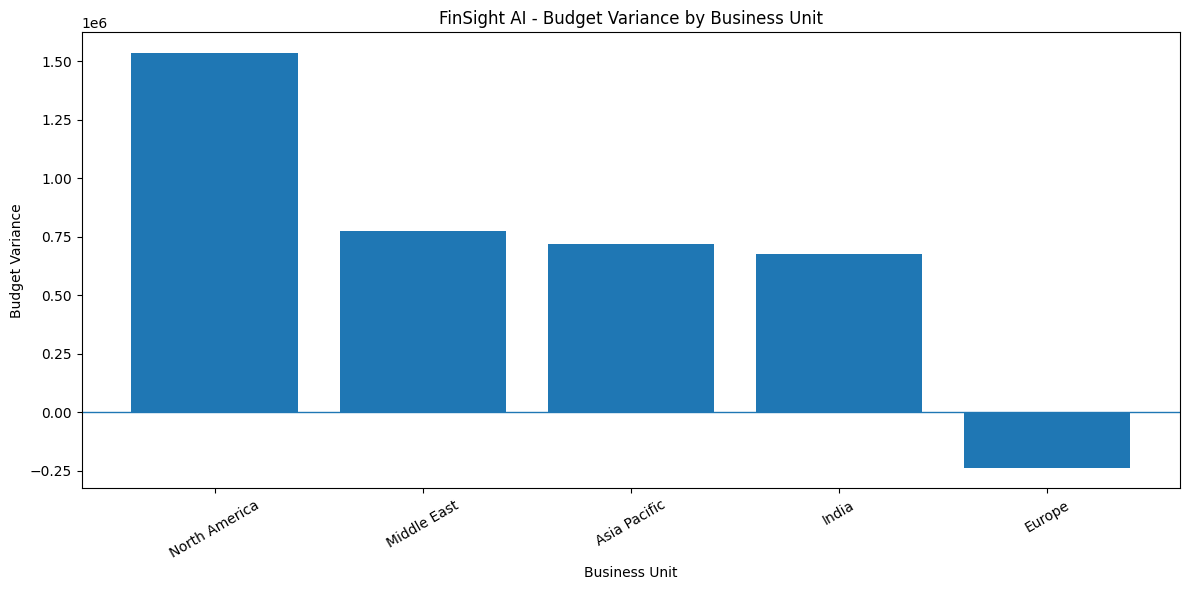

In [34]:
# ============================================================
# STEP 35: BUSINESS UNIT VARIANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    business_unit_analysis["business_unit"],
    business_unit_analysis["variance"]
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("FinSight AI - Budget Variance by Business Unit")
plt.xlabel("Business Unit")
plt.ylabel("Budget Variance")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

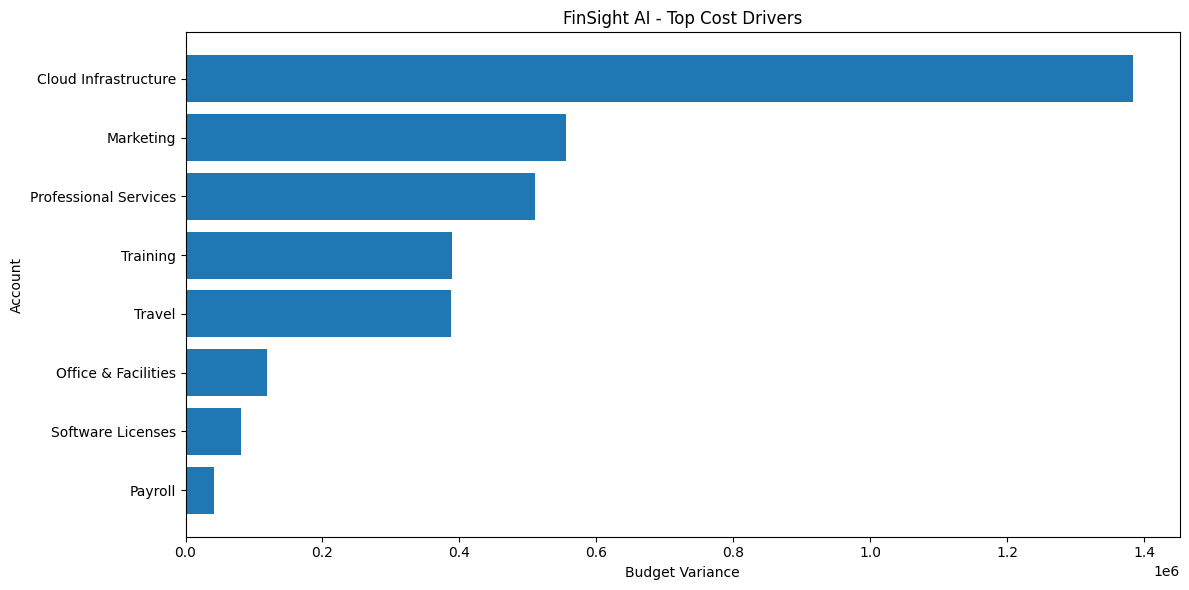

In [35]:
# ============================================================
# STEP 36: TOP COST DRIVER VISUALIZATION
# ============================================================

cost_chart = top_cost_drivers.sort_values(
    "variance",
    ascending=True
)

plt.figure(figsize=(12, 6))

plt.barh(
    cost_chart["account"],
    cost_chart["variance"]
)

plt.title("FinSight AI - Top Cost Drivers")
plt.xlabel("Budget Variance")
plt.ylabel("Account")

plt.tight_layout()
plt.show()

# 🤖 AI Finance Copilot Demo

FinSight AI converts natural-language finance questions into analytical workflows and structured management recommendations.

The agent can investigate:

- Budget vs Actual performance
- Cost drivers
- Financial anomalies
- Revenue outlook

In [36]:
# ============================================================
# STEP 38: FINAL AI FINANCE COPILOT DEMO
# ============================================================

questions = [
    "Why is spending above budget?",
    "Which cost drivers need attention?",
    "Which transactions look unusual?",
    "What is the revenue outlook?"
]

for question in questions:

    result = ai_reasoning_engine(question)

    print("\n" + "=" * 80)
    print("USER QUESTION:")
    print(question)

    print("\nANALYSIS TYPE:")
    print(result["analysis_type"])

    print("\nEXECUTIVE SUMMARY:")
    print(result["executive_summary"])

    print("\nKEY FINDING:")
    print(result["key_finding"])

    print("\nBUSINESS IMPACT:")
    print(result["business_impact"])

    print("\nRECOMMENDED ACTION:")
    print(result["recommended_action"])

    print("\nPRIORITY:", result["priority"])
    print("OWNER:", result["owner"])


USER QUESTION:
Why is spending above budget?

ANALYSIS TYPE:
Budget vs Actual

EXECUTIVE SUMMARY:
Total spending is ₹3,467,195.79 above budget, representing a 4.57% unfavorable variance.

KEY FINDING:
North America has the largest unfavorable business-unit variance of ₹1,534,324.32 (9.94%).

BUSINESS IMPACT:
Continued unfavorable variance may reduce forecast accuracy and put pressure on margins.

RECOMMENDED ACTION:
Investigate the major cost drivers in North America and review budget assumptions.

PRIORITY: P1
OWNER: Finance Business Partner

USER QUESTION:
Which cost drivers need attention?

ANALYSIS TYPE:
Cost Driver Analysis

EXECUTIVE SUMMARY:
Cloud Infrastructure is the largest unfavorable cost driver.

KEY FINDING:
Actual spending of ₹10,814,673.93 versus a budget of ₹9,431,703.12 produces a variance of ₹1,382,970.81.

BUSINESS IMPACT:
The cost driver may materially affect departmental cost performance and forecasts.

RECOMMENDED ACTION:
Review transactions, vendors and utiliza

In [37]:
# ============================================================
# STEP 39: PM ACTION TRACKER
# ============================================================

def create_action_tracker(question):

    result = ai_reasoning_engine(question)

    action_tracker = pd.DataFrame([{
        "Priority": result["priority"],
        "Finding": result["key_finding"],
        "Recommended Action": result["recommended_action"],
        "Owner": result["owner"],
        "Status": "Open"
    }])

    return action_tracker


question = "Why is spending above budget?"

action_tracker = create_action_tracker(question)

display(action_tracker)

,Priority,Finding,Recommended Action,Owner,Status
0,P1,North America has the largest unfavorable busi...,Investigate the major cost drivers in North Am...,Finance Business Partner,Open


# ⚠️ Limitations

This project is a portfolio prototype and is not intended to be used as a production financial system.

### Current limitations

- The dataset is synthetic.
- The revenue forecast is a simple baseline model.
- ML anomaly results require business validation before operational use.
- The current reasoning layer operates without a paid external LLM API.
- Production deployment would require authentication, data governance, monitoring and ERP integration.

---

# 🔮 Future Roadmap

### Version 2

- LLM-powered natural-language interface
- Natural-language-to-SQL with validation
- ERP/API integration
- Scenario and what-if analysis
- Margin forecasting
- Working-capital analytics
- Automated management-report generation
- Human approval workflow for AI recommendations

# 🎯 Conclusion

FinSight AI demonstrates an end-to-end FP&A analytics workflow:

**Financial Data → SQL → Variance Analysis → Machine Learning → Forecasting → Agentic Reasoning → Management Action**

The project combines:

- Finance & FP&A
- Python
- SQL
- Machine Learning
- Data Visualization
- Artificial Intelligence
- Product Management

The objective is not to replace financial judgment with AI, but to help analysts move faster from:

**Data → Evidence → Insight → Action**